# S5:T3 Análisis de supervivencia - Cohortes

En este caso se solicita que hagamos un análisis de churn basado en un modelo de cohortes, así como un análisis de supervivencia, suponiendo que un cliente no ha comprado de nuevo en al menos 6 meses A partir del contenido del fichero: Sales data hemos de responder a las preguntas siguientes:

* ¿Cuál parece ser la mejor cohorte de adquisición de clientes?, ¿Cómo lo valoramos?
* ¿Qué canal de adquisición de usuarios muestra mejores métricas de retención?, ¿El canal online o físico?, ¿Qué tipo de línea de producto es la que genera más ventas repetidas a largo plazo?

## Descripción de campos (`sales_data.xlsx`)

* `transaction_id`: identificador único de cada transacción.
* `product_id`: identificador del producto vendido.
* `customer_id`: identificador del cliente que realiza la compra.
* `transaction_date`: fecha en la que se registra la transacción.
* `online_order`: indicador de canal de compra (`1` = online, `0` = tienda física).
* `order_status`: estado del pedido (por ejemplo, aprobado o cancelado).
* `brand`: marca del producto.
* `product_line`: línea de producto (por ejemplo, Standard, Road, Mountain, Touring).
* `product_class`: clase o gama del producto (por ejemplo, low, medium, high).
* `product_size`: tamaño del producto (small, medium, large).
* `list_price`: precio de venta de catálogo.
* `standard_cost`: coste estándar estimado del producto.
* `product_first_sold_date`: fecha de primera venta del producto en formato numérico serial de Excel (requiere conversión para análisis temporal).



## 1. Load Data and Libraries

Vamos a cargar las librerias necesarias y el conjunto de datos para comenzar nuestro análisis de supervivencia utilizando el método de Cohortes. 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Set options
pd.set_option('display.max_columns', None)
sns.set_style('darkgrid')

# Cargar el dataset
sales_data = pd.read_excel('../data/sales_data.xlsx', header=1)

sales_data

,transaction_id,product_id,customer_id,transaction_date,online_order,order_status,brand,product_line,product_class,product_size,list_price,standard_cost,product_first_sold_date
0,1,2,2950,2017-02-25,0.0,Approved,Solex,Standard,medium,medium,71.49,53.62,41245.0
1,2,3,3120,2017-05-21,1.0,Approved,Trek Bicycles,Standard,medium,large,2091.47,388.92,41701.0
2,3,37,402,2017-10-16,0.0,Approved,OHM Cycles,Standard,low,medium,1793.43,248.82,36361.0
3,4,88,3135,2017-08-31,0.0,Approved,Norco Bicycles,Standard,medium,medium,1198.46,381.10,36145.0
4,5,78,787,2017-10-01,1.0,Approved,Giant Bicycles,Standard,medium,large,1765.30,709.48,42226.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,51,1018,2017-06-24,1.0,Approved,OHM Cycles,Standard,high,medium,2005.66,1203.40,37823.0
19996,19997,41,127,2017-11-09,1.0,Approved,Solex,Road,medium,medium,416.98,312.74,35560.0
19997,19998,87,2284,2017-04-14,1.0,Approved,OHM Cycles,Standard,medium,medium,1636.90,44.71,40410.0
19998,19999,6,2764,2017-07-03,0.0,Approved,OHM Cycles,Standard,high,medium,227.88,136.73,38216.0


La estructura de la data contempla un proceso de multiples transacciones realizadas por un `customer_id` a lo largo del tiempo. Podemos entender entonces que el usuario tiene su primera interaccion, y por tanto, su incio en su ciclo de vida, el a fecha mínima de `transaction_date` mas allá de si esta transacción se encuentra confirmada o no. A partir de la diferenccia entre la fecha de inicio y el conjunto de fechas de las transacciones podemos entonces obtener la `cohorte` a la que pertenece cada cliente y los periodos como tiempo diferencial entre estas fechas y su fecha de inicio. Vamos a calcular esta cohorte en meses, ya que existen demasiadas transacciones para un análisis diario. Existe un campo llamado `product_first_sold_date` pero es la fecha en la que se compró el producto por primera vez, no es la fecha de adquisición del usuario, es ruido. Por tanto, para el análisis y construcción de cohortes, será necesario calcular la fecha de adquisición del usuario como la fecha minima de `transaction_date` para cada `customer_id`.

Existen a su vez disitntas desagregaciones de estudio potencial, como puede ser el `product_class`, `product_line`, `product_size` y `online_order`.

En la desripcion se pide realizar un analisis suponiendo que un cliente no ha comprado nada nuevo en al menos 6 meses, por tanto debemos prefiltrar o truncar lo la derecha la serie temporal de cada cliente. Por tanto, el filtrado requerira  censurar a la derecha para la fecha maxima - 6 meses.

## 2. Transformación de datos y creación de cohortes

In [2]:
# Copy data and truncate to 180 days before the last transaction date
# df = sales_data[
#     sales_data.transaction_date <= sales_data.transaction_date.max() - pd.Timedelta(days=180)
# ].copy()
df = sales_data.copy()

# calculate first pruchase customer
df['first_purchase_date'] = df.groupby('customer_id')['transaction_date'].transform('min')

# Shape of the data
print(f"Shape of the data (n, m): {df.shape}")

Shape of the data (n, m): (20000, 14)


In [3]:
# Info data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   transaction_id           20000 non-null  int64         
 1   product_id               20000 non-null  int64         
 2   customer_id              20000 non-null  int64         
 3   transaction_date         20000 non-null  datetime64[ns]
 4   online_order             19640 non-null  float64       
 5   order_status             20000 non-null  object        
 6   brand                    19803 non-null  object        
 7   product_line             19803 non-null  object        
 8   product_class            19803 non-null  object        
 9   product_size             19803 non-null  object        
 10  list_price               20000 non-null  float64       
 11  standard_cost            19803 non-null  float64       
 12  product_first_sold_date  19803 n

In [4]:
# Describe principal variables
df.describe()

,transaction_id,product_id,customer_id,transaction_date,online_order,list_price,standard_cost,product_first_sold_date,first_purchase_date
count,20000.000000,20000.00000,20000.000000,20000,19640.000000,20000.000000,19803.000000,19803.000000,20000
mean,10000.500000,45.36465,1738.246050,2017-07-01 14:08:05.280000,0.500458,1107.829449,556.046951,38199.776549,2017-02-22 00:31:32.159999744
min,1.000000,0.00000,1.000000,2017-01-01 00:00:00,0.000000,12.010000,7.210000,33259.000000,2017-01-01 00:00:00
25%,5000.750000,18.00000,857.750000,2017-04-01 00:00:00,0.000000,575.270000,215.140000,35667.000000,2017-01-16 00:00:00
50%,10000.500000,44.00000,1736.000000,2017-07-03 00:00:00,1.000000,1163.890000,507.580000,38216.000000,2017-02-08 00:00:00
75%,15000.250000,72.00000,2613.000000,2017-10-02 00:00:00,1.000000,1635.300000,795.100000,40672.000000,2017-03-15 00:00:00
max,20000.000000,100.00000,5034.000000,2017-12-30 00:00:00,1.000000,2091.470000,1759.850000,42710.000000,2017-12-23 00:00:00
std,5773.647028,30.75359,1011.951046,NaN,0.500013,582.825242,405.955660,2875.201110,NaN


### 2.1 Creacion de cohortes a partir de First `transaction_date`

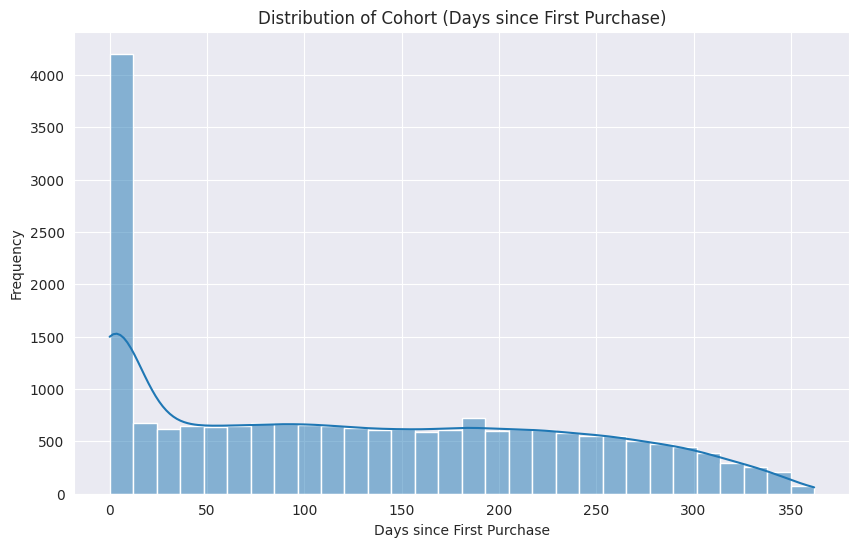

In [5]:
# Cohort
df['days_since_first_purchase'] = (df.transaction_date - df.first_purchase_date).dt.days
df['cohort'] = df['first_purchase_date'].dt.to_period('M')

plt.figure(figsize=(10, 6))

sns.histplot(df['days_since_first_purchase'], bins=30, kde=True)
plt.title('Distribution of Cohort (Days since First Purchase)')
plt.xlabel('Days since First Purchase')
plt.ylabel('Frequency')
plt.show()

Vemos claramente que el priemr dia concentra por tanto la mayoria de las transacciones y como caen estrepitosamnente en las cohortes posteriores. Entendiendo bien la data, es necesario por tanto construir los periodos en meses, ya que un usuario no suele comprar varias veces en un mismo mes, y mucho menos, dia tras dia. Se trata de productos costosos y no de productos de consumo diario. Podemos por tanto, realizar un `month_bin` a partir de las fechas de primera compra y asi encontrar por tanto la retencion real del negocio. Vamos a crear una nueva columna con estos bined

In [6]:
# month bin
df['month_bin'] = pd.cut(
    df['days_since_first_purchase'],
    bins=[0, 15, 30, 60, 90, 120, 150, 180],
    labels=['0-15d', '16-30d', '31-60d', '61-90d', '91-120d', '121-150d', '151-180d'],
    right=False
)

df['month_bin'] = df['month_bin'].cat.add_categories('180+d').fillna('180+d')

## Adding Cohort Months
df['cohort_month'] = (df['transaction_date'].dt.to_period('M') - df['first_purchase_date'].dt.to_period('M')).apply(lambda x: x.n)

In [7]:
# Pivot data
cohort_table = df.groupby(['cohort', 'month_bin']).agg({'customer_id': 'nunique'}).reset_index()

# pivot table
cohort_pivot = cohort_table.pivot(index='cohort', columns='month_bin', values='customer_id').fillna(0)

/tmp/ipykernel_100485/3954879725.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_table = df.groupby(['cohort', 'month_bin']).agg({'customer_id': 'nunique'}).reset_index()


In [8]:
cohort_pivot

month_bin,0-15d,16-30d,31-60d,61-90d,91-120d,121-150d,151-180d,180+d
cohort,,,,,,,,
2017-01,1354,286,491,509,506,468,499,1268
2017-02,800,187,314,293,302,280,300,722
2017-03,484,90,162,181,164,176,173,403
2017-04,336,68,113,134,155,126,134,243
2017-05,210,45,85,80,79,86,61,111
2017-06,122,32,43,44,47,52,45,36
2017-07,77,14,28,24,31,38,14,2
2017-08,51,14,17,21,16,6,0,0
2017-09,23,3,7,7,7,0,0,0


## a. ¿Cuál parece ser la mejor cohorte de adquisición de clientes?, ¿Cómo lo valoramos?

En este caso, podemos ver que la mejor cohorte de adquisición fue el mes de enero, para solo caer posteriormente en febrero, marzo y abril. En este caso, puede tratarse de una temporadidad de campaña de marketing post decembrina.

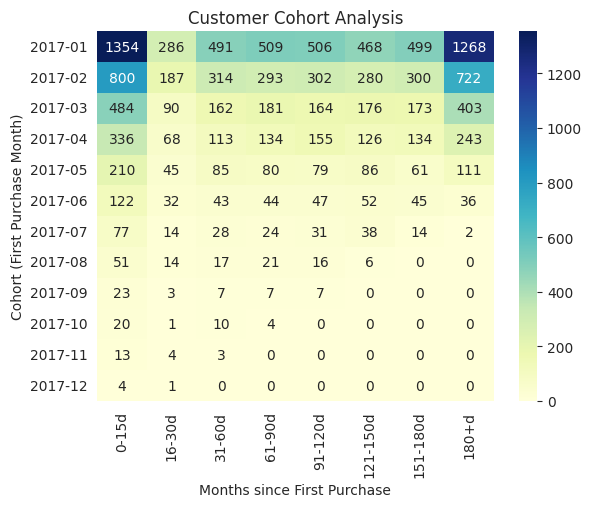

In [49]:
sns.heatmap(cohort_pivot, annot=True, fmt='.0f', cmap='YlGnBu')
plt.title('Customer Cohort Analysis')
plt.xlabel('Months since First Purchase')
plt.ylabel('Cohort (First Purchase Month)')
plt.show()

## b.¿Qué canal de adquisición de usuarios muestra mejores métricas de retención?, ¿El canal online o físico?, ¿Qué tipo de línea de producto es la que genera más ventas repetidas a largo plazo?

In [10]:
from lifelines import KaplanMeierFitter

In [24]:
p  = df[['customer_id', 'transaction_date', 'online_order', 'product_line']].sort_values(['customer_id', 'transaction_date'], ascending = [True, True]).copy()

p['shifted_t'] = p.groupby('customer_id')['transaction_date'].shift(1)
p['delta'] = (p['transaction_date'] - p['shifted_t']).dt.days

p['event'] = np.where(p['delta'] > 180, 1, 0)

p['cycle_churn'] = p.groupby('customer_id')['event'].cumsum()

# Filtered data
p = p[(p['cycle_churn'] == 0) | ((p['cycle_churn'] == 1) & (p['event'] == 1))][['customer_id', 'transaction_date', 'event', 'online_order', 'product_line']]

data_kmf = df.merge(
    p, on =[ "customer_id", "transaction_date"], how = "inner"
)

data_kmf = data_kmf.groupby(['customer_id']).agg(
    duration = ('transaction_date', lambda x: (x.max() - x.min()).days),
    last_date = ('transaction_date', 'max'),
    event = ('event', 'max'),
    cohort_month = ('cohort', 'max')
)

# Gest First Channel of Acquisition and product line
first_channel = p.groupby('customer_id')['online_order'].first().reset_index()
first_product_line = p.groupby('customer_id')['product_line'].first().reset_index()
data_kmf = data_kmf.merge(first_channel, on='customer_id', how='left').rename(columns={'online_order': 'channel_adquisition'})
data_kmf = data_kmf.merge(first_product_line, on='customer_id', how='left').rename(columns={'product_line': 'first_product_line'})

# Fix event
data_kmf['event'] = np.where(
    (data_kmf['event'] == 1), 1,
    np.where(
        (data_kmf['last_date'] <= df['transaction_date'].max() - pd.Timedelta(days=180)), 1, 0
    )
)

En el enunciado, se establece que un Churn se produce cuando un cliente no ha comprado nada nuevo en al menos 6 meses, por tanto, debemos realizar el trigger de churn para configurar el evento y por tanto, ya tener el resto que es censura. Para ello, vamos a encontrar el periodo de tiempo hasta que ocurre el evento de churn siendo la fecha de corte, la fecha máxima de transacción menos 6 meses. Por tanto, todas aquellas transacciones posteriores a esta fecha de corte, se consideran censura. Solo con este trigger de churn, podemos entonces realizar el análisis de supervivencia medinate Kaplan Meier.

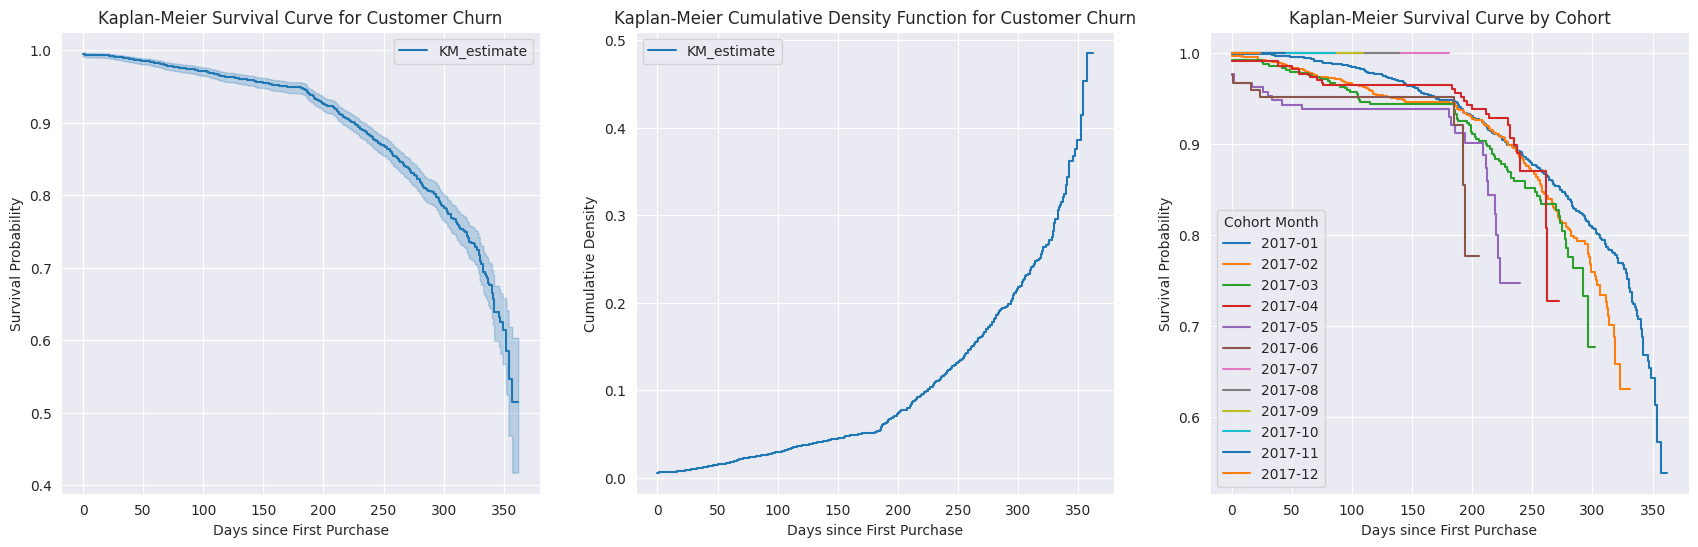

In [13]:
km = KaplanMeierFitter(alpha = 0.05)
km.fit(
    durations = data_kmf['duration'],
    event_observed = data_kmf['event']
)

# Survival Curve
fig, ax = plt.subplots(figsize=(21, 6), ncols = 3)
km.plot_survival_function(ci_show = True, ax = ax[0])
ax[0].set_title('Kaplan-Meier Survival Curve for Customer Churn')
ax[0].set_xlabel('Days since First Purchase')
ax[0].set_ylabel('Survival Probability')

# Cumulative Density Function
km.plot_cumulative_density(ci_show = False, ax = ax[1])
ax[1].set_title('Kaplan-Meier Cumulative Density Function for Customer Churn')
ax[1].set_xlabel('Days since First Purchase')
ax[1].set_ylabel('Cumulative Density')

# Calculate survival curve by cohort
for cohort in np.sort(data_kmf['cohort_month'].unique()):
    km.fit(
        durations = data_kmf[data_kmf['cohort_month'] == cohort]['duration'],
        event_observed = data_kmf[data_kmf['cohort_month'] == cohort]['event'],
        label = f'{cohort}'
    )
    km.plot_survival_function(ci_show = False, ax = ax[2])
ax[2].set_title('Kaplan-Meier Survival Curve by Cohort')
ax[2].set_xlabel('Days since First Purchase')
ax[2].set_ylabel('Survival Probability')
ax[2].legend(title='Cohort Month')

plt.show()

Bien, ya tenemos un poco inormacion de como va la supervivencia de los clientes. Teniendo un umbral de 6 meses para considerar un cliente como churn. Vemos como cae la supervivencia muy suavemente en esos piemros 180 dias para ir bajando con mayor velocidad hasta practicamente los 365 dias. La curva de densidad de supervivencia muestra la misma tendencia en terminos de probabilidad.

Ahora, cuando desagregamos esto por cohorte, vemos claramente como el la tabla anterior, que las primeras tres cohortes parecen ser las que mejor retienen a los clientes, además, son las cohortes mas grandes. Esas primeras tres parecen tener un rendimeinto similar, pero van degradando su supervivencia con respecto a la cohorte anterior. Basicamente esa primera cohorte de Enero 2027, sin lugar a dudas, es la que mejor retiene a los clientes.

Para construir las mismas curvas de supervivencia por canal, asumimos entonces que se trata de la supervivencia sobre el canal de adquisición. Usar el calculo de KM sobre el conjunto de transacciones por Online o Físico por separado, puede introducir causa efecto erroneo y dar resultados no necesarimente correctos. Al tratarse de adquisición, tiene mas sentido realizar el análisis sobre esta variable en ese punto exacto. Esto nos permite evaluar, a nivel de lógica de negocio, si el tipo de canal de primera impresión es relevante para la supervivencia del cliente a largo plazo, como evento de primera impresión clave.

In [15]:
data_kmf.channel_adquisition.value_counts()

channel_adquisition
0.0    1766
1.0    1727
Name: count, dtype: int64

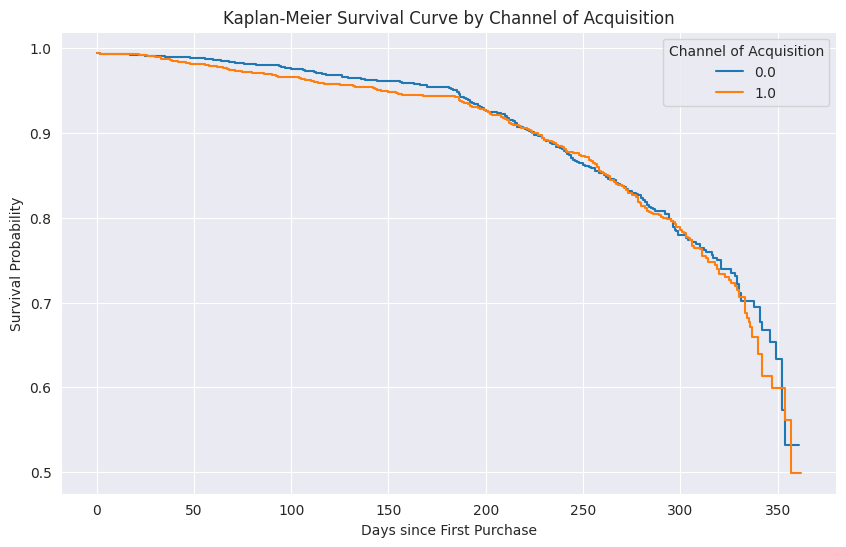

In [18]:
# For channel adquisition
plt.figure(figsize=(10, 6))

for channel in data_kmf[data_kmf['channel_adquisition'].notna()]['channel_adquisition'].unique():
    km.fit(
        durations = data_kmf[data_kmf['channel_adquisition'] == channel]['duration'],
        event_observed = data_kmf[data_kmf['channel_adquisition'] == channel]['event'],
        label = f'{channel}'
    )
    km.plot_survival_function(ci_show = False)

plt.title('Kaplan-Meier Survival Curve by Channel of Acquisition')
plt.xlabel('Days since First Purchase')
plt.ylabel('Survival Probability')
plt.legend(title='Channel of Acquisition')
plt.show()

El canal de adquisición físico parece tener un ligero mejor rendimiento de retención en esas etapas inciales, pero a partir de los 180 días, terminan convergiendo en un rendimiento similar. Sin embargo, aunque exista una diferencia, no es tan apreciable. Para determinar si esto es estadísticamente significativo, podríamos realizar un test de log-rank para comparar las curvas de supervivencia entre ambos grupos.

In [22]:
# Import Log-Rank Test
from lifelines.statistics import logrank_test

# Perform Log-Rank Test
results = logrank_test(
    data_kmf[data_kmf['channel_adquisition'] == 1]['duration'],
    data_kmf[data_kmf['channel_adquisition'] == 0]['duration'],
    event_observed_A = data_kmf[data_kmf['channel_adquisition'] == 1]['event'],
    event_observed_B = data_kmf[data_kmf['channel_adquisition'] == 0]['event']
)

# print Results
print(f"Test Statistic: {results.test_statistic:.4f}")
print(f"Log-Rank Test p-value: {results.p_value:.4f}")

if results.p_value < 0.05:
    print("The difference in survival curves between Online and Physical channels is statistically significant.")
else:
    print("The difference in survival curves between Online and Physical channels is not statistically significant.")

Test Statistic: 0.2858
Log-Rank Test p-value: 0.5929
The difference in survival curves between Online and Physical channels is not statistically significant.


Con un p-value de 0.59, sin lugar a dudas no podemos rechazar la hipótesis nula de que no existen diferencias significativas entre ambos grupos. Por tanto, no existe evidencia estadística suficiente para afirmar que un canal de adquisición retiene mejor que el otro.

Ahora, vamos a realizar un último análisis por linea de producto, para responder esa última pregunta planteada. Para ello, realizaremos la misma consideración. Es decir, usaremos el producto de primera compra como linea de prodcuto para la adquisición y evaluar la supervivencia en lineas de producto, lo cuál puede darnos ideas equivocadas, ya que no existe causa necesaria de churn real de negocio que un usuario deje de comprar una linea de proctucto en particular. 

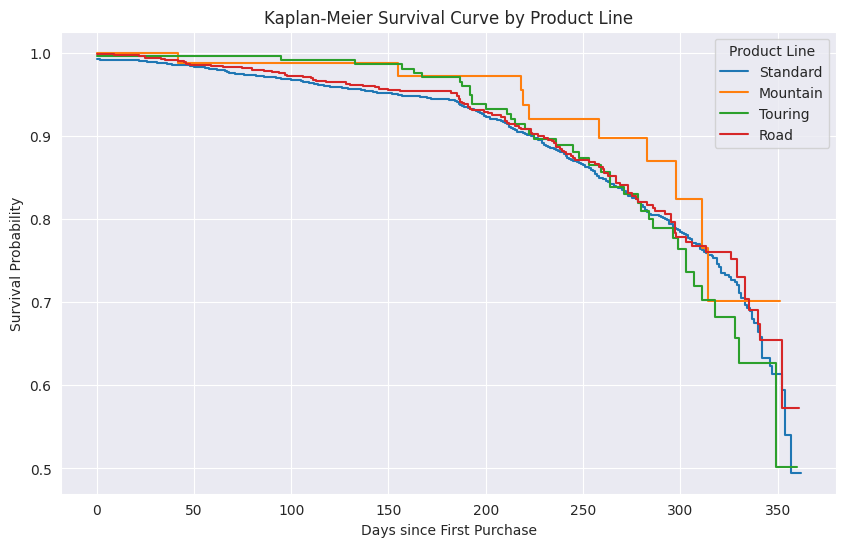

In [25]:
# For product line
plt.figure(figsize=(10, 6))

for product_line in data_kmf[data_kmf['first_product_line'].notna()]['first_product_line'].unique():
    km.fit(
        durations = data_kmf[data_kmf['first_product_line'] == product_line]['duration'],
        event_observed = data_kmf[data_kmf['first_product_line'] == product_line]['event'],
        label = f'{product_line}'
    )
    km.plot_survival_function(ci_show = False)

plt.title('Kaplan-Meier Survival Curve by Product Line')
plt.xlabel('Days since First Purchase')
plt.ylabel('Survival Probability')
plt.legend(title='Product Line')
plt.show()

Bien, en este caso podemos ver como la linea de **Mountain** parece tener el mejor rendimeinto de rentención a largo plazo. **Touring** también parece compartir rendimientos similares en la supervivencia en los primeros 150 dias, para despues conv erger con el resto de las lineas de producto. **Road** y **Standard** tienen comporamients muy similares, con una brecha final a partir de los 280 dias a favor del **Road** y **Touring** perdiendo algo mas de usuarios. 

Por tanto, podemo concluir que la linea de producto **Mountain** tiene curva de supervivencia, siendo esta curva mas alata en las cohortes a lo largo del tiempo. Ahora, los escalones pronunciados pueden deberse a que el conjunto de adquisiciones en esa linea de procuto es relativamente pequeño, por tanto cada evento de churn tiene un impacto más pronunciadoen la curva. Cómo hemos realizado anteriormente, es necesario realizar un test de long-rank en pares para determinar si existen diferencias apreciables.

In [28]:
## Create Log-Rank Test for Product Line in pairs

# Combinations of product lines
from itertools import combinations


for pA, pB in combinations(data_kmf['first_product_line'].dropna().unique(), 2):
    results = logrank_test(
        data_kmf[data_kmf['first_product_line'] == pA]['duration'],
        data_kmf[data_kmf['first_product_line'] == pB]['duration'],
        event_observed_A = data_kmf[data_kmf['first_product_line'] == pA]['event'],
        event_observed_B = data_kmf[data_kmf['first_product_line'] == pB]['event']
    )
    print(f"Comparing {pA} vs {pB}:")
    print(f"Test Statistic: {results.test_statistic:.4f}")
    print(f"Log-Rank Test p-value: {results.p_value:.4f}")
    if results.p_value < 0.05:
        print("The difference in survival curves between the two product lines is statistically significant.\n")
    else:
        print("The difference in survival curves between the two product lines is not statistically significant.\n")

Comparing Standard vs Mountain:
Test Statistic: 0.9747
Log-Rank Test p-value: 0.3235
The difference in survival curves between the two product lines is not statistically significant.

Comparing Standard vs Touring:
Test Statistic: 0.1147
Log-Rank Test p-value: 0.7349
The difference in survival curves between the two product lines is not statistically significant.

Comparing Standard vs Road:
Test Statistic: 0.3120
Log-Rank Test p-value: 0.5764
The difference in survival curves between the two product lines is not statistically significant.

Comparing Mountain vs Touring:
Test Statistic: 1.0567
Log-Rank Test p-value: 0.3040
The difference in survival curves between the two product lines is not statistically significant.

Comparing Mountain vs Road:
Test Statistic: 0.6146
Log-Rank Test p-value: 0.4331
The difference in survival curves between the two product lines is not statistically significant.

Comparing Touring vs Road:
Test Statistic: 0.3551
Log-Rank Test p-value: 0.5512
The differ

Como sospechabamos, ningun test de Long-Rank entre pares de lineas de producto muestra diferencias estadísticamente significativas para recharzar su propia hipótesis nula. Por tanto, aunque la grafíca muestren cierta diferencia, no existe evidencia suficiente. **Mountain** parece tener un mejor rendimiento, pero su distribución es relativamente pequeña, ya que su conjunto de usuarios es pequeño.

Ahora, tambien nos preguntan que canal de venta realiza mayores ventas repetidas a largo plazo. Para ello, debemos calcular cadencia por cohorte. Es decir, el número de compras por cliente a lo largo del tiempo para un mismo producto.

/tmp/ipykernel_100485/3966614394.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  product_lines_grouped = df_first_product.groupby(['first_product_line', 'month_bin']).agg(


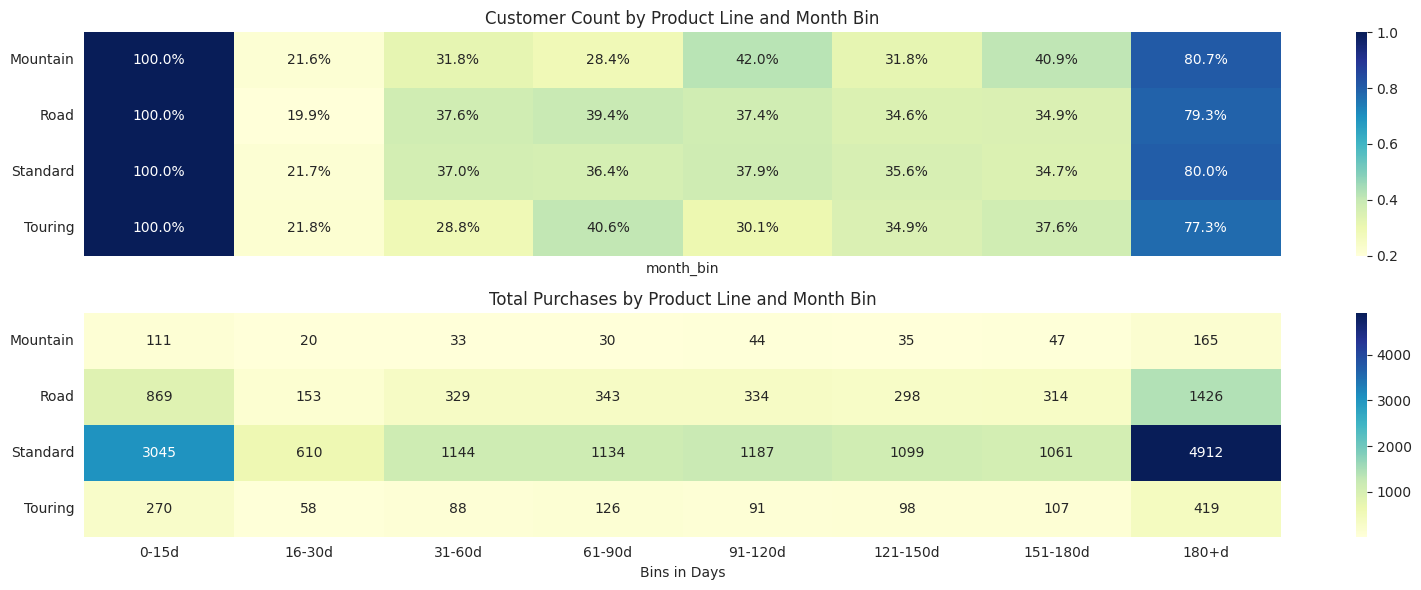

In [48]:
first_purchase_per_customer = df.groupby(['customer_id']).agg(
        first_purchase_date = ('transaction_date', 'min'),
        first_product_line = ('product_line', 'first'),
).reset_index()

df_first_product = df.merge(first_purchase_per_customer, on='customer_id', how='left')

product_lines_grouped = df_first_product.groupby(['first_product_line', 'month_bin']).agg(
        customer_count = ('customer_id', 'nunique'),
        total_purchases = ('transaction_id', 'nunique'),
).reset_index()


# For metrics, pivot table and plot heatmap by product line and month bin
fig, ax = plt.subplots(figsize=(16, 6), nrows = 2, sharex = True)
metrics = ['customer_count', 'total_purchases']
for metric in metrics:
    pivot_table = product_lines_grouped.pivot(index='first_product_line', columns='month_bin', values=metric)
    if metric == "customer_count":
        # Divide the all row by first column to get the percentage of customers retained
        pivot_table = pivot_table.div(pivot_table.iloc[:, 0], axis=0)
        sns.heatmap(pivot_table, annot=True, fmt='.1%', cmap='YlGnBu', ax=ax[metrics.index(metric)])
    else:
        sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlGnBu', ax=ax[metrics.index(metric)])
    ax[metrics.index(metric)].set_title(f'{metric.replace("_", " ").title()} by Product Line and Month Bin')
    ax[metrics.index(metric)].set_ylabel('')

ax[1].set_xlabel('Bins in Days')
plt.tight_layout()
plt.show()

En términos de retención, y por tanto de compras repetidas por parte de los usuarios, ninguna linea de producto parece ofrecer un rendimiento claramente superior a las demas. Esto confirma sin duda lo visto en el análisis de supervivencia. Llegados hasta aquí realizar una validación de Chi-cuadrado para determinar si existen diferencias aprecibales no es necesario.